# Image denoising

In [1]:
from utils import (
    prox_mcp, mcp, mcp_torch, lmo_spectral, lmo_nuclear, TV, TV_adj, TV_torch, 
    prox_l1, lmo_block_l1, lmo_l2
)

from BCD import load_dataset

from denoising_experiments import (
    run_experiment, plot_scaling, plot_images, plot_loss, plot_ssims,
    plot_primal_gap_and_penalty,
)

import numpy as np
import matplotlib.pyplot as plt
import torch

noise_level = 0.05
# lam = 0.05#2*noise_level
lam = 0.05
mu = 2.#3.

dataset = 'camera'
# dataset = "spectrometer"
# dataset = "olivetti" 
# dataset = "football"
# dataset = "miserables"
# dataset = "low_rank_synthetic"

K = 10_000 if dataset == 'olivetti' else 10_000
store_WH_every = 100 if dataset == 'olivetti' else 1
def g(X):
    Px, Py = X
    return np.sum(mcp(Px, lam, mu)) + np.sum(mcp(Py, lam, mu))
    # return np.sum(np.abs(Px)) + np.sum(np.abs(Py))

def g_torch(X):
    Px, Py = X
    return torch.sum(mcp_torch(Px, lam, mu)) + torch.sum(mcp_torch(Py, lam, mu))
    # return torch.sum(torch.abs(Px)) + torch.sum(torch.abs(Py))

prox = lambda x, b : prox_mcp(x, b, lam, mu)
# prox = prox_l1
T = TV
T_adj = lambda x : TV_adj(x[0], x[1])
# lmo = lambda M : lmo_spectral(M, 1., 6)
# lmo = lambda M : lmo_block_l1(M, 1.)
lmo = lambda M : lmo_l2(M, 1.)
# lmo = lambda M : lmo_nuclear(M, 1.)
comment = ""
save = False
scale = False


## Add noise to the image

0.008465512696419247 0.9994933599059728


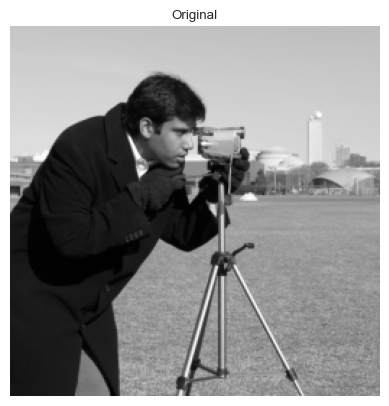

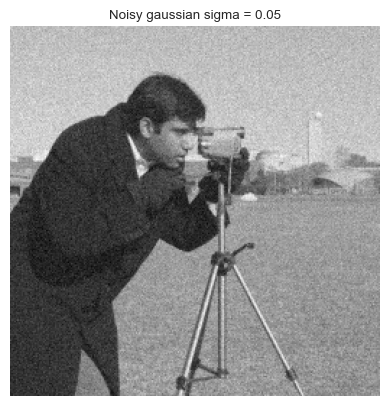

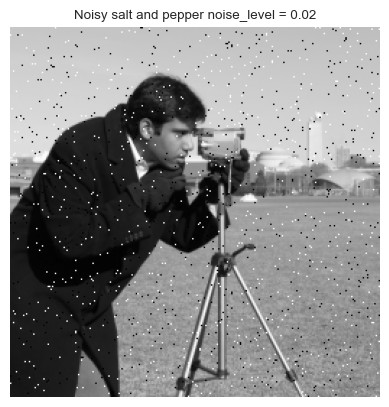

In [2]:
from utils import noisy_image
# import odl

D = load_dataset(dataset)
# data_odl = odl.phantom.white_noise(D, mean=D, stddev=20, seed=1807)

print(D.min(), D.max())

if scale:
    # Min-Max Scaling
    min_vals = D.min()
    max_vals = D.max()

    D = (D - min_vals) / (max_vals - min_vals)

img = plt.imshow(D)
img.set_cmap('gray')
plt.axis('off')
plt.title('Original')
plt.show()

# Add gaussian noise to the image
Y_gaussian = noisy_image(D, noise_level=noise_level)

img = plt.imshow(Y_gaussian)
img.set_cmap('gray')
plt.axis('off')
plt.title(f'Noisy gaussian sigma = {noise_level}')
plt.show()

# Add salt and pepper noise
Y_salt_and_pepper = noisy_image(D, noise_type='salt_and_pepper', noise_level=0.02)

img = plt.imshow(Y_salt_and_pepper) 
img.set_cmap('gray')
plt.axis('off')
plt.title('Noisy salt and pepper noise_level = 0.02')
plt.show()

## Experiments for gaussian noise

In [3]:
X = D + np.random.randn(*D.shape) * 0.1
px, py = TV(X)
print(px.shape, py.shape)

(256, 256) (256, 256)


In [4]:
T_adj(prox(T(X), 0.1)).shape

(256, 256)

In [5]:
results = run_experiment(
    dataset, 
    T = T,
    T_torch = TV_torch,
    T_adj = T_adj,
    # noise_type = 'salt_and_pepper',
    noise_type = 'gaussian',
    noise_level = noise_level,
    K = K, 
    g = g,
    g_torch = g_torch,
    prox = prox,    
    lmo = lmo,
    comment = comment,
    save = save,
    scale = scale,
)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:59<00:00, 169.04it/s]


Subgradient descent loss: 57.27228927612305


100%|██████████| 10000/10000 [01:14<00:00, 134.29it/s]


Gamons (Spectral LMO) loss: 61.71041514795098


...

Gamons (L2 LMO) loss: 64.27657170805338


100%|██████████| 10000/10000 [01:14<00:00, 133.41it/s]


Gamons (Nuclear LMO) loss: 49.324752780571515


100%|██████████| 10000/10000 [00:41<00:00, 242.26it/s]

Variable Smoothing BW loss: 63.38504594996692


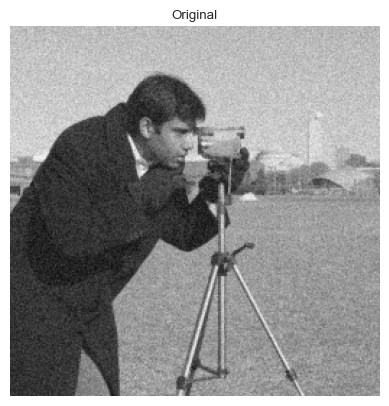

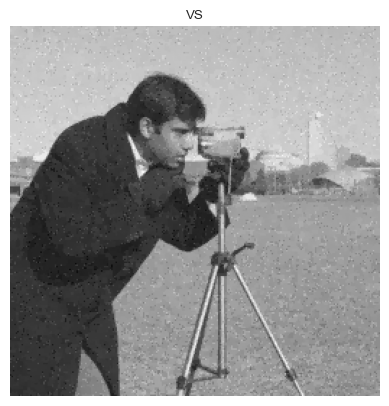

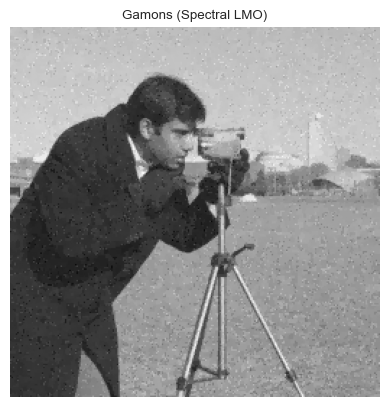

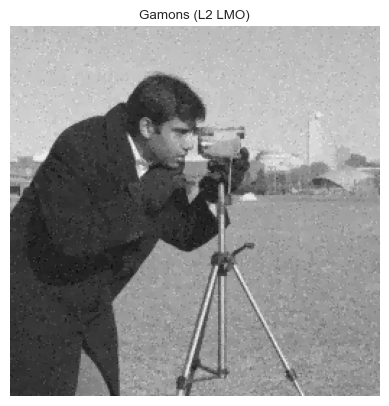

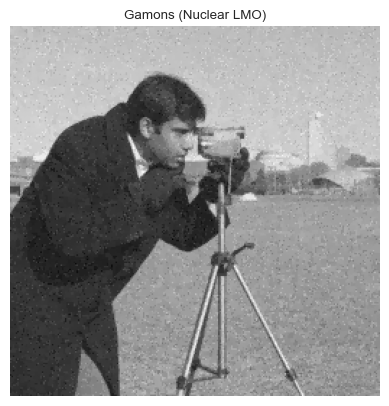

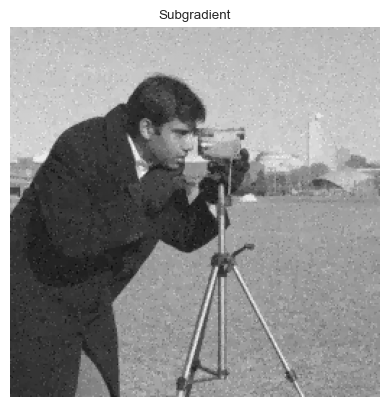

In [6]:
plot_images(results)

VS : 2.840e-03
GAMONS (Spectral LMO) : 2.765e-03
GAMONS (L2 LMO) : 2.880e-03
GAMONS (Nuclear LMO) : 2.210e-03
Subgradient : 2.566e-03


KeyError: 'gamons (p = 2/3, q = 1/3)'

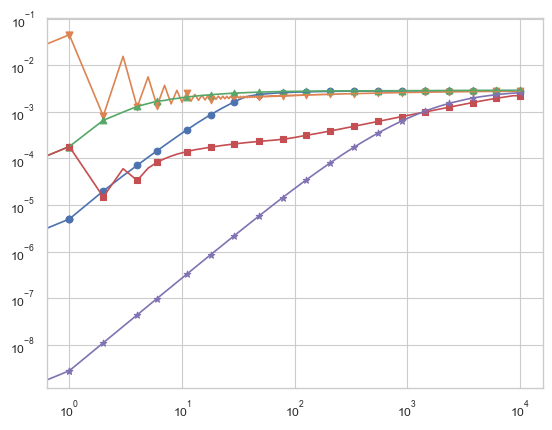

In [7]:
plot_loss(results)

VS : 1.626e+02
GAMONS (Spectral LMO) : 1.633e+02
GAMONS (L2 LMO) : 1.626e+02
GAMONS (Nuclear LMO) : 1.638e+02
Subgradient : 1.617e+02


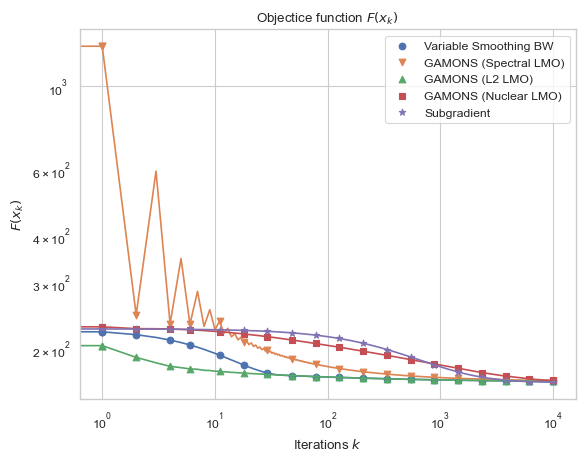

VS : 9.919e+01
GAMONS (p = 2/3, q = 1/3) : 1.144e+02


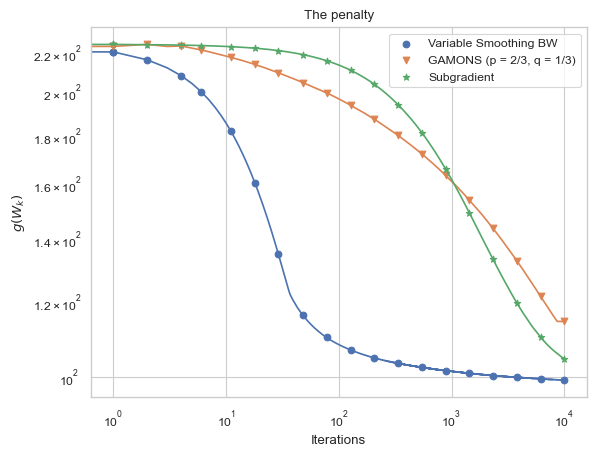

In [8]:
plot_primal_gap_and_penalty(results)

VS : 6.670e-01
GAMONS (Spectral LMO) : 6.723e-01
GAMONS (L2 LMO) : 6.700e-01
GAMONS (Nuclear LMO) : 6.442e-01
Subgradient : 6.511e-01


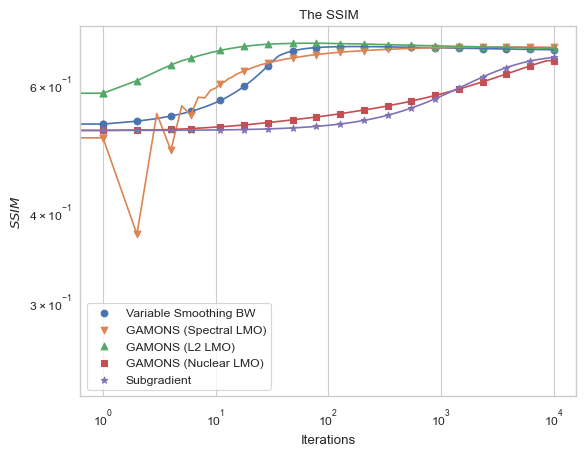

In [9]:
plot_ssims(results)

In [ ]:
from skimage.metrics import structural_similarity as ssim

orig_img = results['original']
img2 = results['gamons (p = 2/3, q = 1/3)']['WH']
mssim, ssim_img = ssim(orig_img, img2, full=True, data_range=1)
print(f'MSSIM gamons (p = 2/3, q = 1/3): {mssim}')

MSSIM gamons (p = 2/3, q = 1/3): 0.8138704295228901


In [ ]:
# img2 = results['gamons (p = 7/12, q = 1/3)']['WH']
# mssim, ssim_img = ssim(orig_img, img2, full=True, data_range=1)
# print(f'MSSIM gamons (p = 7/12, q = 1/3): {mssim}')


In [ ]:
img2 = results['subgradient']['WH']
mssim, ssim_img = ssim(orig_img, img2, full=True, data_range=1)
print(f'MSSIM subgradient: {mssim}')


MSSIM subgradient: 0.8373112831550406


In [ ]:
img2 = results['variable smoothing']['WH']
mssim, ssim_img = ssim(orig_img, img2, full=True, data_range=1)
print(f'MSSIM variable smoothing: {mssim}')


MSSIM variable smoothing: 0.8162850461474039
